# Tutorial 2: Surface Codes and Lattice Surgery

How do local check measurements protect a logical qubit, and how can they connect two logical qubits?

This notebook accompanies **Tutorial 03: Rotated Surface Codes**, following its patch orientation, gate order, seam checks, and measurement-based CNOT. Read it after [the Shor notebook](shor_tutorial.ipynb); familiarity with Pauli operators, stabilizers, and CNOT is assumed.

Run the cells in order. We will draw the numbered patches and circuits, compare correct and incorrect measurement schedules, trace hook errors, and verify joint measurements and CNOT. All quantum circuits and simulations use **Loom**. NumPy supports small exact algebra checks, and Matplotlib draws the figures. These are ideal experiments; noisy fault-tolerant decoding is a separate topic.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from itertools import product
from IPython.display import display, Markdown
from importlib.metadata import version
from loom.eka import Circuit, Channel, ChannelType, PauliOperator, Lattice
from loom_rotated_surface_code.code_factory import RotatedSurfaceCode
from loom.cliffordsim import Engine
from loom.cliffordsim.operations import Reset, Hadamard, CNOT, Measurement, X, Y, Z

ORANGE, TEAL = "#bd622a", "#087f8c"
plt.rcParams.update({"figure.dpi": 110, "font.size": 11})
print("Loom", version("el-loom"))

Loom 0.4.0


## 1. Read the same patch as the tutorial

Data labels increase **left to right, starting at the bottom row**. An orange face measures an $X$ product; a teal face measures a $Z$ product. At distance five, the bottom-left neighboring checks are
$$S_X=X_0X_1X_5X_6,\qquad S_Z=Z_1Z_2Z_6Z_7.$$
They share qubits 1 and 6. Two anticommuting overlaps give two minus signs, so the complete checks commute.

Loom labels qubits by coordinates. Here $(x,y,0)$ means data qubit $q=x+dy$ on a distance-$d$ patch; we draw increasing $y$ upward. `weight_2_stab_is_first_row=False` selects the tutorial's checkerboard. This fixes the geometry; we specify the tutorial's CNOT order explicitly below.

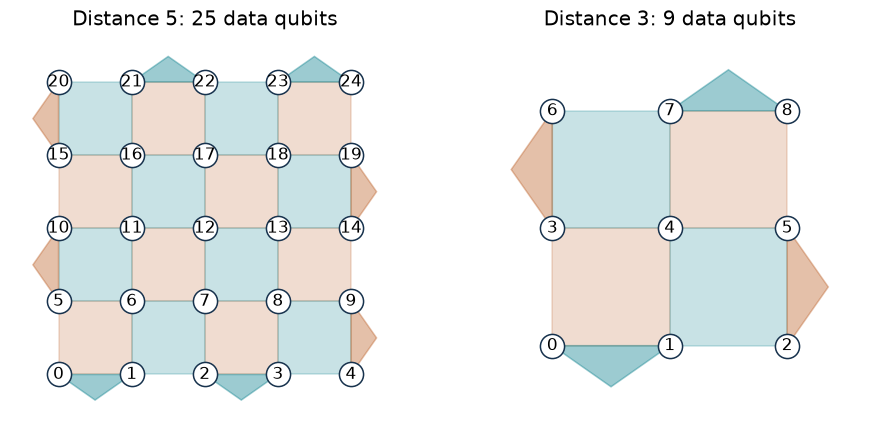

Every X/Z check pair commutes.


In [2]:
def make_patch(d):
    return RotatedSurfaceCode.create(
        d, d, Lattice.square_2d((d+1, d+1)),
        unique_label=f"patch{d}", weight_2_stab_is_first_row=False,
    )


def pauli(letter, ids, d=3):
    return PauliOperator(letter * len(ids), [(q % d, q // d, 0) for q in ids])


def labels(op, d):
    return [x + d*y for x, y, _ in op.data_qubits]


def draw_patch(ax, block, d):
    for s in block.stabilizers:
        xy = np.array([q[:2] for q in s.data_qubits], dtype=float)
        color = ORANGE if s.pauli_type == "X" else TEAL
        if len(xy) == 4:
            centre = xy.mean(axis=0)
            order = np.argsort(np.arctan2(*(xy-centre)[:, ::-1].T))
            ax.add_patch(Polygon(xy[order], color=color, alpha=.22))
        else:
            centre = xy.mean(axis=0)
            offset = np.zeros(2)
            axis = 0 if xy[0, 0] == xy[1, 0] else 1
            offset[axis] = -.35 if centre[axis] == 0 else .35
            ax.add_patch(Polygon([xy[0], centre+offset, xy[1]], color=color, alpha=.4))
    for q in range(d*d):
        ax.scatter(q%d, q//d, s=250, color="white", edgecolor="#17324d", zorder=3)
        ax.text(q%d, q//d, str(q), ha="center", va="center", zorder=4)
    ax.set(xlim=(-.65,d-.35), ylim=(-.65,d-.35), aspect="equal")
    ax.axis("off")


patch5, patch3 = make_patch(5), make_patch(3)
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, block, d in zip(axes, [patch5, patch3], [5, 3]):
    draw_patch(ax, block, d)
    ax.set_title(f"Distance {d}: {d*d} data qubits")
plt.show()
assert all(a.commutes_with(b) for a in patch5.stabilizers for b in patch5.stabilizers)
print("Every X/Z check pair commutes.")

### Logical operators and logical states

For the distance-three patch, use $\overline X=X_0X_1X_2$ horizontally and $\overline Z=Z_0Z_3Z_6$ vertically. They commute with all checks but anticommute with each other. The eight independent checks leave a two-dimensional space:
$$|\psi_L\rangle=\alpha|0_L\rangle+\beta|1_L\rangle.$$
Here $|0_L\rangle$ and $|1_L\rangle$ have logical $Z$ signs $+1$ and $-1$, respectively. They are **nine-qubit states**, not individual physical qubits. Likewise $|+_L\rangle=(|0_L\rangle+|1_L\rangle)/\sqrt2$ has logical $X$ sign $+1$.

We first inspect their amplitudes with NumPy. Starting from $|0\rangle^{\otimes9}$, apply each $X$-check projector $(I+S_X)/2$ and normalize. This selects the all-$+1$ check branch; it is a mathematical preparation, not a deterministic encoding circuit. The bit strings below are written in order $q_0q_1\cdots q_8$.

In [3]:
checks = list(patch3.stabilizers)
logical_x, logical_z = pauli("X", [0,1,2]), pauli("Z", [0,3,6])
assert all(logical_x.commutes_with(s) and logical_z.commutes_with(s) for s in checks)
assert not logical_x.commutes_with(logical_z)


def apply_pauli(state, op, d=3):
    # Vector index bit q denotes data qubit q (least-significant bit first).
    indices = np.arange(len(state))
    destination = indices.copy()
    phase = np.ones(len(state), dtype=complex)
    for letter, q in zip(op.pauli, labels(op, d)):
        bit = (indices >> q) & 1
        if letter in "ZY":
            phase *= (-1.)**bit
        if letter == "Y":
            phase *= 1j
        if letter in "XY":
            destination ^= 1 << q
    result = np.empty_like(state, dtype=complex)
    result[destination] = phase * state
    return result


zero_L = np.zeros(512, dtype=complex)
zero_L[0] = 1
for s in checks:
    zero_L = (zero_L + apply_pauli(zero_L, s))/2
zero_L /= np.linalg.norm(zero_L)
one_L = apply_pauli(zero_L, logical_x)
plus_L = (zero_L + one_L)/np.sqrt(2)
for state in [zero_L, one_L, plus_L]:
    assert all(np.allclose(apply_pauli(state, s), state) for s in checks)
for name, state in [("0_L", zero_L), ("1_L", one_L)]:
    terms = [format(i,"09b")[::-1] for i in np.flatnonzero(abs(state)>1e-10)]
    print(f"|{name}>: equal positive amplitudes 1/sqrt({len(terms)}) on")
    print("  " + ", ".join(terms))
assert np.allclose(apply_pauli(one_L, logical_z), -one_L)
assert np.allclose(apply_pauli(plus_L, logical_x), plus_L)

|0_L>: equal positive amplitudes 1/sqrt(16) on
  000000000, 110110000, 001001000, 111111000, 000100100, 110010100, 001101100, 111011100, 111100011, 001010011, 110101011, 000011011, 111000111, 001110111, 110001111, 000111111
|1_L>: equal positive amplitudes 1/sqrt(16) on
  111000000, 001110000, 110001000, 000111000, 111100100, 001010100, 110101100, 000011100, 000100011, 110010011, 001101011, 111011011, 000000111, 110110111, 001001111, 111111111


## 2. Measure a check with an ancilla

A $Z$ check uses an ancilla prepared in $|0\rangle$: the data control CNOTs into it, then we measure it in $Z$. An $X$ check uses an ancilla in $|+\rangle$: it controls CNOTs into the data, then we measure it in $X$.

The helper below implements these **ideal ancilla measurements in Loom's bundled Clifford simulator**. It also handles mixed $X/Z$ products by changing the $X$ factors to the $Z$ basis before measuring and undoing that change afterward. `0` means a $+1$ result and `1` means $-1$. Loom's `is_random` flag tells us whether that measurement was intrinsically random in the current stabilizer state.

In [4]:
def measure_product(op, qubit_ids, ancilla, name, bias=.5):
    factors = [(p, qubit_ids[q]) for p, q in zip(op.pauli, op.data_qubits)]
    assert all(p in "XZ" for p, _ in factors)
    if all(p == "X" for p, _ in factors):
        return ([Reset(ancilla, state="+")]
                + [CNOT(ancilla, q) for _, q in factors]
                + [Measurement(ancilla, basis="X", label=name, bias=bias)])
    rotations = [Hadamard(q) for p, q in factors if p == "X"]
    return (rotations + [Reset(ancilla)]
            + [CNOT(q, ancilla) for _, q in factors]
            + [Measurement(ancilla, label=name, bias=bias)] + rotations)


def run_loom(operations, nqubits, seed=0):
    engine = Engine(operations, nqubits=nqubits, seed=seed)
    engine.run()
    records = {name: value for tick, entries in engine.data_store.measurements.items()
               if tick != "time_step" for name, value in entries.items()}
    return records


def bit(records, name):
    return int(records[name]["measurement_result"])


ids3 = {(q%3, q//3, 0): q for q in range(9)}
z_check = pauli("Z", [0,1])
for error in [[], [X(0)]]:
    records = run_loom(error + measure_product(z_check, ids3, 9, "check"), 10)
    print("X0 error:" , bool(error), "→ Z0 Z1 result:", bit(records, "check"))
    assert bit(records, "check") == bool(error)

X0 error: False → Z0 Z1 result: 0
X0 error: True → Z0 Z1 result: 1


## 3. Why the four-step sequence matters

Return to the tutorial's distance-five labels. For $S_X=X_0X_1X_5X_6$, the ancilla visits **5, 0, 6, 1** (N shape). For $S_Z=Z_1Z_2Z_6Z_7$, it visits **6, 7, 1, 2** (Z shape).

In a Loom `Circuit`, each inner tuple is one simultaneous layer. Its constructor rejects two gates that use the same qubit in that layer. We build these four layers explicitly; ancilla preparation and readout sit outside them.

The simulator executes the two disjoint gates within each layer sequentially; disjoint gates commute, so this preserves the layer's ideal action.

In the circuit diagrams, a dot is the control and $\oplus$ is the target. A vertical line crossing a wire does not act on it unless a gate symbol is present.

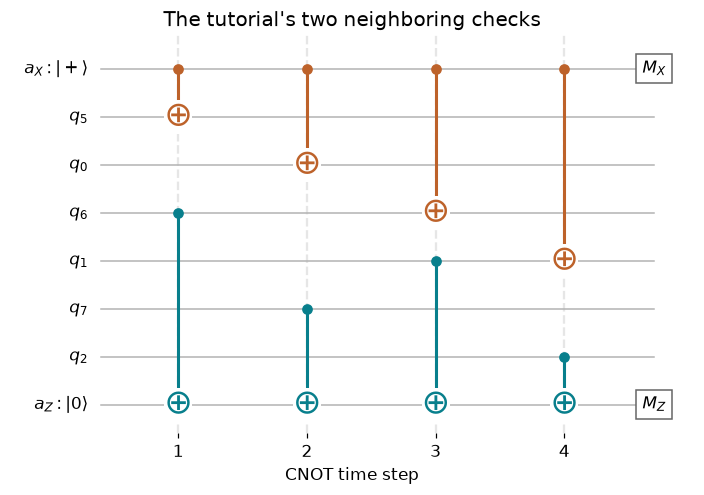

Loom accepts all four layers: no shared-qubit collisions.


In [5]:
wire_ids = [25, 5, 0, 6, 1, 7, 2, 26]  # ancillas 25 and 26; tutorial data labels
channels = {q: Channel(type=ChannelType.QUANTUM, label=str(q)) for q in wire_ids}


def cx(control, target):
    return Circuit("cx", channels=(channels[control], channels[target]))


def neighbor_schedule(x_order, z_order):
    return Circuit("neighbor checks", circuit=tuple(
        (cx(25, xq), cx(zq, 26)) for xq, zq in zip(x_order, z_order)))


x_order, z_order = [5,0,6,1], [6,7,1,2]
good_schedule = neighbor_schedule(x_order, z_order)


def draw_schedule(circuit, title):
    fig, ax = plt.subplots(figsize=(8, 4.7))
    rows = {q: len(wire_ids)-1-i for i, q in enumerate(wire_ids)}
    for q, y in rows.items():
        ax.plot([.4, 4.7], [y,y], color=".7", lw=1)
        label = r"$a_X:|+\rangle$" if q == 25 else r"$a_Z:|0\rangle$" if q == 26 else f"$q_{{{q}}}$"
        ax.text(.3,y,label,ha="right",va="center")
    for t, layer in enumerate(circuit.circuit, 1):
        ax.axvline(t, color=".9", ls="--", zorder=0)
        for gate in layer:
            c,tgt = [int(ch.label) for ch in gate.channels]
            color = ORANGE if c == 25 else TEAL
            ax.plot([t,t], [rows[c],rows[tgt]],color=color,lw=2)
            ax.plot(t,rows[c],"o",color=color,ms=6)
            ax.text(t,rows[tgt],"⊕",color=color,ha="center",va="center",fontsize=22,
                    bbox=dict(facecolor="white",edgecolor="none",pad=0))
    for q,basis in [(25,"X"),(26,"Z")]:
        ax.text(4.7,rows[q],f"$M_{basis}$",ha="center",va="center",
                bbox=dict(facecolor="white",edgecolor=".4"))
    ax.set(xticks=range(1,5), xlabel="CNOT time step", yticks=[], title=title,
           xlim=(-.3,5), ylim=(-.6,7.7))
    for spine in ax.spines.values(): spine.set_visible(False)
    plt.show()


draw_schedule(good_schedule, "The tutorial's two neighboring checks")
print("Loom accepts all four layers: no shared-qubit collisions.")

### No collision does not guarantee the right measurement

The $Z$ interaction comes before the $X$ interaction at **both** shared qubits: 6 and 1. To see why that matters, suppose these two data bits begin at $00$. In the $|1\rangle$ part of the $X$ ancilla, both are flipped. Reading before both flips gives $00$; reading after both gives $11$. Both have even parity. Reading before just one flip changes that parity.

Change the $X$ visit order to **1, 0, 6, 5**. There are still no collisions, but now $X$ precedes $Z$ at qubit 1 while $Z$ precedes $X$ at qubit 6.

We prepare a state with both check signs $+1$, then run each schedule. In the correct circuit both results must be 0. In the changed circuit the ancillas become coupled, and their readouts are random even with no physical error.

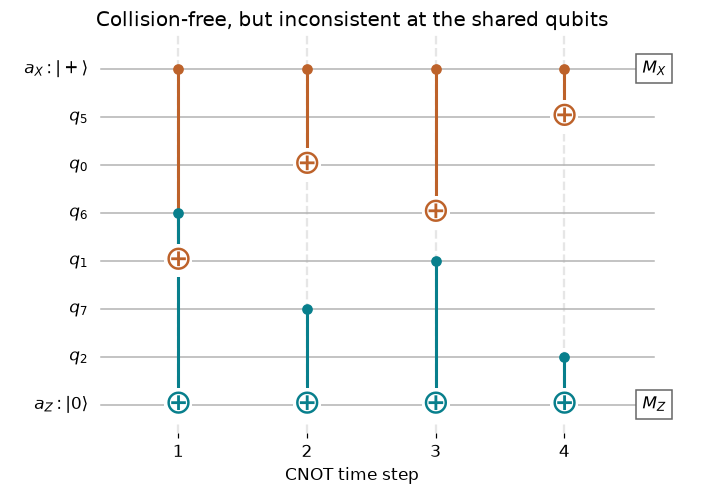

Tutorial order (X bit, Z bit): [(0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0)]
Changed order (X bit, Z bit): [(1, 1), (0, 1), (1, 0), (1, 0), (0, 0), (0, 0), (1, 1), (0, 0), (0, 1), (1, 0), (1, 0), (1, 0)]


In [6]:
bad_schedule = neighbor_schedule([1,0,6,5], z_order)
draw_schedule(bad_schedule, "Collision-free, but inconsistent at the shared qubits")


def schedule_operations(circuit):
    # Translate the explicit Loom Circuit's CNOTs to Loom simulator operations.
    return [CNOT(*[int(ch.label) for ch in gate.channels])
            for layer in circuit.circuit for gate in layer]


ids5 = {(q%5,q//5,0): q for q in range(25)}
sx, sz = pauli("X", [0,1,5,6], 5), pauli("Z", [1,2,6,7], 5)
# Starting from all-zero data, selecting SX=+1 also preserves SZ=+1.
# bias=0 selects result 0 when the preparation measurement is random.
preparation = measure_product(sx, ids5, 27, "prepare", bias=0)
for name, schedule in [("Tutorial order",good_schedule), ("Changed order",bad_schedule)]:
    ops = (preparation + [Reset(25,state="+"),Reset(26)]
           + schedule_operations(schedule)
           + [Measurement(25,basis="X",label="x"), Measurement(26,label="z")])
    rows = [run_loom(ops,28,seed=s) for s in range(12)]
    print(name, "(X bit, Z bit):", [(bit(r,"x"),bit(r,"z")) for r in rows])
    assert all(bool(r["z"]["is_random"]) == (name == "Changed order") for r in rows)
    if name == "Tutorial order":
        assert all(bit(r,"x") == bit(r,"z") == 0 for r in rows)

The random flags establish that the changed circuit fails; we need not infer it from a small sample. We can also check the good order for **every possible input**. CNOTs permute computational-basis states. The next cell compares that permutation with all $Z$ interactions followed by all $X$ interactions, on the six data qubits and two ancillas. Equality of the full permutations also establishes equality on superpositions.

In [7]:
def cnot_permutation(gates):
    position = {q:i for i,q in enumerate(wire_ids)}
    output = np.arange(2**len(wire_ids))
    for gate in gates:
        c,t = [position[int(ch.label)] for ch in gate.channels]
        output ^= ((output >> c) & 1) << t
    return output


serial = [cx(q,26) for q in z_order] + [cx(25,q) for q in x_order]
parallel = [gate for layer in good_schedule.circuit for gate in layer]
changed = [gate for layer in bad_schedule.circuit for gate in layer]
assert np.array_equal(cnot_permutation(serial), cnot_permutation(parallel))
assert not np.array_equal(cnot_permutation(serial), cnot_permutation(changed))
print("All 256 basis inputs: tutorial order equals sequential checks; changed order does not.")

All 256 basis inputs: tutorial order equals sequential checks; changed order does not.


### Why N-shaped and Z-shaped orders?

There is a second reason to choose the order carefully: a fault on an ancilla can spread through its remaining CNOTs. An $X$ on a control spreads to the target; a $Z$ on a target spreads to the control.

Insert the propagating fault after the **second** CNOT. The $X$ ancilla spreads $X$ to qubits 6 and 1, a vertical pair. The $Z$ ancilla spreads $Z$ to qubits 1 and 2, a horizontal pair. These **hook errors** lie across, rather than along, the corresponding shortest logical strings: logical $X$ is horizontal and logical $Z$ vertical.

The small propagation calculation uses exactly the CNOTs in the Loom schedule. We ignore the overall Pauli phase because only the error support matters here.

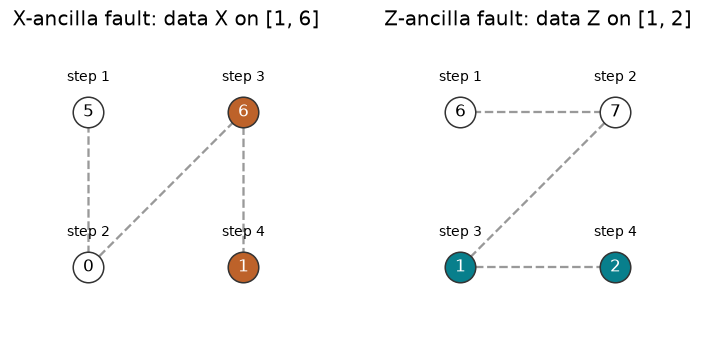

Fault after 0 gates: 4 data errors → equivalent weight 0
Fault after 1 gates: 3 data errors → equivalent weight 1
Fault after 2 gates: 2 data errors → equivalent weight 2
Fault after 3 gates: 1 data errors → equivalent weight 1
Fault after 4 gates: 0 data errors → equivalent weight 0


In [8]:
def propagate_fault(gates, fault_qubit, basis):
    xs, zs = ({fault_qubit}, set()) if basis == "X" else (set(), {fault_qubit})
    for gate in gates:
        c,t = [int(ch.label) for ch in gate.channels]
        if c in xs: xs.symmetric_difference_update({t})
        if t in zs: zs.symmetric_difference_update({c})
    return xs, zs


fig, axes = plt.subplots(1,2,figsize=(8,3.5))
for ax, basis, order, ancilla in zip(axes,["X","Z"],[x_order,z_order],[25,26]):
    own_gates = [cx(25,q) if basis=="X" else cx(q,26) for q in order]
    xs,zs = propagate_fault(own_gates[2:],ancilla,basis)
    hook = (xs if basis=="X" else zs) - {ancilla}
    assert hook == set(order[2:])
    xy = np.array([(q%5,q//5) for q in order])
    ax.plot(xy[:,0],xy[:,1],"--",color=".6")
    for step,(q,(x,y)) in enumerate(zip(order,xy),1):
        ax.scatter(x,y,s=400,color=(ORANGE if basis=="X" else TEAL) if q in hook else "white",
                   edgecolor=".2",zorder=3)
        ax.text(x,y,str(q),ha="center",va="center",color="white" if q in hook else "black")
        ax.text(x,y+.2,f"step {step}",ha="center",fontsize=9)
    ax.set(title=f"{basis}-ancilla fault: data {basis} on {sorted(hook)}",aspect="equal",
           xlim=(xy[:,0].min()-.5,xy[:,0].max()+.5),ylim=(-.4,1.5))
    ax.axis("off")
plt.show()
for k in range(5):
    # A fault after k CNOTs reaches the remaining 4-k data sites.
    # Multiplying by the four-body check replaces that suffix by its complement.
    print(f"Fault after {k} gates: {4-k} data errors → equivalent weight {min(k,4-k)}")

A four-data-qubit error is the measured stabilizer itself; a three-qubit error differs from a one-qubit error by that stabilizer. The two-qubit case makes the orientation important. This does not by itself prove fault tolerance: readout errors, other circuit faults, and decoding still matter.

### All checks in the same four-step interval

The same corner labels extend across the patch. Boundary checks retain their two corner times and leave their ancillas idle at the missing steps. We construct a full distance-three round with these rules. Loom checks every layer for collisions, including boundary checks.

In [9]:
def patch_schedule(block, d):
    all_channels = {q: Channel(type=ChannelType.QUANTUM,label=str(q))
                    for q in range(d*d + len(block.stabilizers))}
    layers = [[] for _ in range(4)]
    for i,s in enumerate(block.stabilizers):
        support = {q[:2] for q in s.data_qubits}
        # Locate the face, including virtual faces just outside the boundary.
        candidates = [(x,y) for x in range(-1,d) for y in range(-1,d)
                      if {(a,b) for a,b in [(x,y),(x+1,y),(x,y+1),(x+1,y+1)]
                          if 0<=a<d and 0<=b<d} == support]
        assert len(candidates) == 1
        x,y = candidates[0]
        corners = ([(x,y+1),(x,y),(x+1,y+1),(x+1,y)] if s.pauli_type=="X"
                   else [(x,y+1),(x+1,y+1),(x,y),(x+1,y)])
        for t,(a,b) in enumerate(corners):
            if (a,b) not in support: continue
            data,ancilla = a+d*b,d*d+i
            c,target = (ancilla,data) if s.pauli_type=="X" else (data,ancilla)
            layers[t].append(Circuit("cx", channels=(all_channels[c],all_channels[target])))
    return Circuit("full check round", circuit=tuple(tuple(layer) for layer in layers))


round3 = patch_schedule(patch3,3)
round5 = patch_schedule(patch5,5)
print("Collision-free CNOT counts per layer:")
for d,circuit in [(3,round3),(5,round5)]:
    print(f"d={d}:", [len(layer) for layer in circuit.circuit])


def prepare_patch(state="0", offset=0, ancilla=17, prefix="prep"):
    # Ideal selected preparation branch: all checks +1.
    ids = {q:offset+i for q,i in ids3.items()}
    ops = [Reset(offset+q,state="+" if state in ["+","-"] else "0") for q in range(9)]
    for i,s in enumerate(checks):
        ops += measure_product(s,ids,ancilla,f"{prefix}{i}",bias=0)
    if state in ["1","-"]:
        op = logical_x if state=="1" else logical_z
        ops += [(X if state=="1" else Z)(ids[q]) for q in op.data_qubits]
    return ops


def full_round():
    ops = [Reset(9+i,state="+" if s.pauli_type=="X" else "0") for i,s in enumerate(checks)]
    ops += schedule_operations(round3)
    ops += [Measurement(9+i,basis=s.pauli_type,label=f"s{i}") for i,s in enumerate(checks)]
    return ops


for state in ["0","1","+","-"]:
    records = run_loom(prepare_patch(state) + full_round(),18)
    assert all(bit(records,f"s{i}")==0 and not records[f"s{i}"]["is_random"] for i in range(8))
print("The scheduled round returns eight +1 checks on all four logical states.")

Collision-free CNOT counts per layer:
d=3: [6, 6, 6, 6]
d=5: [20, 20, 20, 20]
The scheduled round returns eight +1 checks on all four logical states.


## 4. Error strings and recovery

An error flips precisely the checks it anticommutes with. Their bits form the **syndrome**. Along a string, interior overlaps cancel; the remaining violated checks identify its visible ends. A logical string crosses the patch and has no syndrome.

For example, $X_0$, $X_0X_1$, and $X_0X_1X_2=\overline X$ extend along the bottom row. The last error changes the logical state while leaving every check sign unchanged.

In [10]:
def syndrome(error):
    return tuple(int(not error.commutes_with(s)) for s in checks)


for qs in [[0],[0,1],[0,1,2]]:
    error = pauli("X",qs)
    print("X on",qs,"→ syndrome",syndrome(error),
          "→ flips logical Z:",not error.commutes_with(logical_z))

# Test actual ancilla readouts against the predicted syndrome for every single-site Pauli.
for letter,gate in [("X",X),("Y",Y),("Z",Z)]:
    for q in range(9):
        records = run_loom(prepare_patch() + [gate(q)] + full_round(),18)
        assert tuple(bit(records,f"s{i}") for i in range(8)) == syndrome(pauli(letter,[q]))
print("All 27 single-qubit errors give the predicted scheduled ancilla syndromes.")

X on [0] → syndrome (0, 0, 0, 0, 0, 0, 1, 0) → flips logical Z: True
X on [0, 1] → syndrome (0, 0, 0, 1, 0, 0, 0, 0) → flips logical Z: True
X on [0, 1, 2] → syndrome (0, 0, 0, 0, 0, 0, 0, 0) → flips logical Z: True
All 27 single-qubit errors give the predicted scheduled ancilla syndromes.


A decoder chooses a correction from the syndrome. Under an assumption of at most one data-qubit error, a lookup table suffices. Different one-qubit errors may share a syndrome, but their difference is a stabilizer, so either correction restores the logical state.

That assumption matters: $X_0X_1$ and $X_2$ have the same syndrome. Applying the one-qubit correction $X_2$ to the two-qubit error leaves $\overline X$. A cleared syndrome alone does not prove successful recovery.

In [11]:
recovery = {}
for letter in "XYZ":
    for q in range(9):
        e = pauli(letter,[q])
        recovery.setdefault(syndrome(e),e)
for letter in "XYZ":
    for q in range(9):
        e = pauli(letter,[q])
        correction = recovery[syndrome(e)]
        for state in [zero_L, plus_L]:
            restored = apply_pauli(apply_pauli(state,e),correction)
            assert np.isclose(abs(np.vdot(state,restored)),1)
assert syndrome(pauli("X",[0,1])) == syndrome(pauli("X",[2]))
print("Lookup recovery restores all single-qubit errors; the two-qubit counterexample leaves logical X.")

Lookup recovery restores all single-qubit errors; the two-qubit counterexample leaves logical X.


### Repeated measurements distinguish changes in time

A persistent data error changes a check sign until it is corrected. A single wrong readout can change just one reported bit. Compare successive results using $\delta_t=s_t\oplus s_{t-1}$. The following histories illustrate the difference; they are prescribed examples, not a noise simulation.

In [12]:
histories = {"No fault":[0,0,0,0,0], "Persistent data error":[0,0,1,1,1],
             "One wrong readout":[0,0,1,0,0]}
for name,s in histories.items():
    changes = [s[t]^s[t-1] for t in range(1,len(s))]
    print(f"{name:22s} results {s}   changes {changes}")

No fault               results [0, 0, 0, 0, 0]   changes [0, 0, 0, 0]
Persistent data error  results [0, 0, 1, 1, 1]   changes [0, 1, 0, 0]
One wrong readout      results [0, 0, 1, 0, 0]   changes [0, 1, 1, 0]


Repeated rounds give a decoder both spatial and temporal information. A full noisy memory experiment also needs preparation/readout boundary conditions and a circuit-level noise model. The written tutorial develops that next; we now follow its transition to lattice surgery.

## 5. Join patches to measure logical $ZZ$

Use two distance-three patches side by side, labeled $L_0,\ldots,L_8$ and $R_0,\ldots,R_8$. Their facing edges support
$$\overline Z_L=Z_{L_2}Z_{L_5}Z_{L_8},\qquad \overline Z_R=Z_{R_0}Z_{R_3}Z_{R_6}.$$
Prepare three bridge **data** qubits $b_0,b_1,b_2$ in $|+\rangle$, ordered bottom to top. Separate ancillas measure the seam checks:
$$\begin{aligned}
G_1&=Z_{L_2}Z_{b_0},&G_2&=Z_{b_0}Z_{b_1}Z_{R_0}Z_{R_3},\\
G_3&=Z_{L_5}Z_{L_8}Z_{b_1}Z_{b_2},&G_4&=Z_{b_2}Z_{R_6}.
\end{aligned}$$
Each bridge factor occurs twice in $G_1G_2G_3G_4$ and cancels. Their product is $P=\overline Z_L\overline Z_R$, with outcome bit $m=g_1\oplus g_2\oplus g_3\oplus g_4$.

This reveals whether the two logical $Z$ values agree, without revealing them separately. In particular, an even result retains both $|00\rangle_L$ and $|11\rangle_L$ and their superposition.

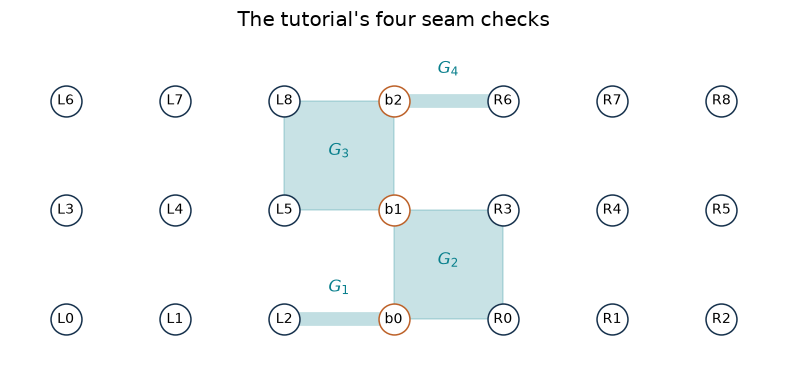

In [13]:
L, R, bridge = list(range(9)), list(range(9,18)), [18,19,20]
# Use the actual seam geometry as Loom coordinates; integer IDs are for simulation.
seam_coords = ({L[q]:(q%3,q//3,0) for q in range(9)}
               | {R[q]:(4+q%3,q//3,0) for q in range(9)}
               | {bridge[i]:(3,i,0) for i in range(3)})
seam_ids = {coordinate:q for q,coordinate in seam_coords.items()}


def seam_pauli(letter, qubits):
    return PauliOperator(letter*len(qubits),[seam_coords[q] for q in qubits])


supports = [[L[2],bridge[0]], [bridge[0],bridge[1],R[0],R[3]],
            [L[5],L[8],bridge[1],bridge[2]], [bridge[2],R[6]]]
G = [seam_pauli("Z",qs) for qs in supports]
Z_left, Z_right = seam_pauli("Z",[L[2],L[5],L[8]]), seam_pauli("Z",[R[0],R[3],R[6]])
P = seam_pauli("Z",[L[2],L[5],L[8],R[0],R[3],R[6]])
XX = seam_pauli("X",L[:3]+R[:3])
# For Z-only products, symmetric difference cancels repeated factors.
product_support = set()
for g in G: product_support.symmetric_difference_update(g.data_qubits)
assert product_support == set(P.data_qubits)

fig,ax = plt.subplots(figsize=(10,4))
for i,qs in enumerate(supports):
    xy=np.array([seam_coords[q][:2] for q in qs],float)
    if len(xy)==4:
        centre=xy.mean(0); order=np.argsort(np.arctan2(*(xy-centre)[:,::-1].T))
        ax.add_patch(Polygon(xy[order],color=TEAL,alpha=.22))
    else: ax.plot(xy[:,0],xy[:,1],color=TEAL,lw=9,alpha=.25)
    centre=xy.mean(0)
    ax.text(centre[0],centre[1]+(.25 if len(qs)==2 else 0),f"$G_{i+1}$",color=TEAL,ha="center")
for q,(x,y,_) in seam_coords.items():
    label=f"L{q}" if q<9 else f"R{q-9}" if q<18 else f"b{q-18}"
    ax.scatter(x,y,s=410,color="white",edgecolor=ORANGE if q>=18 else "#17324d",zorder=3)
    ax.text(x,y,label,ha="center",va="center",zorder=4,fontsize=9)
ax.set(aspect="equal",xlim=(-.5,6.5),ylim=(-.5,2.6),title="The tutorial's four seam checks")
ax.axis("off");plt.show()

### Why the old boundary checks must change

The old left boundary check $B_L=X_{L_2}X_{L_5}$ anticommutes with $G_1$, so measuring it after $G_1$ randomizes the next $G_1$ result. This happens without a data error. The right check $B_R=X_{R_3}X_{R_6}$ similarly conflicts with $G_2$.

Replace them during the merge by
$$H_L=X_{L_2}X_{L_5}X_{b_0}X_{b_1},\qquad H_R=X_{b_1}X_{b_2}X_{R_3}X_{R_6}.$$
The bridge factors make every overlap with a seam $Z$ check even. These replacements start at $+1$ and keep that sign during the ideal merge.

In [14]:
B_left, B_right = seam_pauli("X",[L[2],L[5]]), seam_pauli("X",[R[3],R[6]])
H_left = seam_pauli("X",[L[2],L[5],bridge[0],bridge[1]])
H_right = seam_pauli("X",[bridge[1],bridge[2],R[3],R[6]])
assert not B_left.commutes_with(G[0]) and not B_right.commutes_with(G[1])
assert all(h.commutes_with(g) for h in [H_left,H_right] for g in G)
ops = (measure_product(G[0],seam_ids,21,"before")
       + measure_product(B_left,seam_ids,21,"old_boundary")
       + measure_product(G[0],seam_ids,21,"after"))
records = run_loom(ops,22)
assert not records["before"]["is_random"] and records["after"]["is_random"]
print("G1 initially definite; remeasuring G1 after the old X check is random.")
print("Both replacement X checks commute with every seam check.")
# Retain all old checks except these two boundary checks.
def embed_check(s, patch):
    return seam_pauli(s.pauli_type,[patch[q] for q in labels(s,3)])
old_checks = [embed_check(s,patch) for patch in [L,R] for s in checks]
merged_checks = [s for s in old_checks if s != B_left and s != B_right] + [H_left,H_right] + G
assert all(a.commutes_with(b) for a in merged_checks for b in merged_checks)

G1 initially definite; remeasuring G1 after the old X check is random.
Both replacement X checks commute with every seam check.


### Split and keep track of the outcomes

Measure the bridges in $X$ to separate the patches. Write their bits as $r_0,r_1,r_2$. The restored boundary-check signs are $(-1)^{r_0\oplus r_1}$ and $(-1)^{r_1\oplus r_2}$.

There is also a logical sign to track. On the middle bridge, a $| -\rangle$ result assigns opposite signs to its $|0\rangle$ and $|1\rangle$ components. The seam relation
$$G_1G_2=Z_{L_2}Z_{b_1}Z_{R_0}Z_{R_3}$$
transfers this effect to $Z_{L_2}Z_{R_0}Z_{R_3}=Z_{L_2}Z_{R_6}\overline Z_R$ on the data, up to an overall sign. Including all three readouts gives
$$D_{\mathbf r}=Z_{L_2}^{r_0\oplus r_1}Z_{R_6}^{r_1\oplus r_2}\overline Z_R^{r_1}.$$

A **Pauli frame** records this known correction and uses it to interpret later results. If $D_{\mathbf r}$ anticommutes with a measured operator, flip its reported bit; otherwise leave it unchanged.

We start with $|+_L\rangle|+_L\rangle$, measure the four seam checks, and split. After interpreting the frame, joint $ZZ$ must have bit $m$, and joint $XX$ must have bit 0. Both correlations should be definite, whereas an individual logical $Z$ remains random. This is an ideal merge–split demonstration; the seam checks here run sequentially, not as a noisy fault-tolerant schedule.

In [15]:
def seam_experiment(seed=0, probe=None):
    ops = prepare_patch("+",0,21,"left") + prepare_patch("+",9,21,"right")
    ops += [Reset(q,state="+") for q in bridge]
    for j,g in enumerate(G): ops += measure_product(g,seam_ids,21,f"g{j}")
    ops += [Measurement(q,basis="X",label=f"r{i}") for i,q in enumerate(bridge)]
    for name,op in [("zz",P),("xx",XX),("left_boundary",B_left),("right_boundary",B_right)]:
        ops += measure_product(op,seam_ids,21,name)
    if probe is not None: ops += measure_product(probe,seam_ids,21,"individual")
    return run_loom(ops,22,seed)


rows=["| g1 g2 g3 g4 | r0 r1 r2 | m | raw XX bit | framed XX bit |", "|---|---|---|---|---|"]
for seed in range(8):
    records=seam_experiment(seed,Z_left)
    g=[bit(records,f"g{j}") for j in range(4)]
    r=[bit(records,f"r{i}") for i in range(3)]
    m=int(np.bitwise_xor.reduce(g))
    # Accumulate the Z support of D_r; repeated Z factors cancel.
    frame_support=set()
    for active,qs in [(r[0]^r[1],[L[2]]),(r[1]^r[2],[R[6]]),(r[1],[R[0],R[3],R[6]])]:
        if active: frame_support.symmetric_difference_update(qs)
    xx_support={seam_ids[q] for q in XX.data_qubits}
    framed_xx=bit(records,"xx") ^ (len(frame_support & xx_support)%2)
    assert bit(records,"zz")==m and framed_xx==0
    assert all(not records[name]["is_random"] for name in ["zz","xx","left_boundary","right_boundary"])
    assert bit(records,"left_boundary")==r[0]^r[1]
    assert bit(records,"right_boundary")==r[1]^r[2]
    assert records["individual"]["is_random"]
    rows.append(f"| {''.join(map(str,g))} | {''.join(map(str,r))} | {m} | {bit(records,'xx')} | {framed_xx} |")
display(Markdown("\n".join(rows)))
assert seam_experiment(0,Z_right)["individual"]["is_random"]

| g1 g2 g3 g4 | r0 r1 r2 | m | raw XX bit | framed XX bit |
|---|---|---|---|---|
| 0001 | 010 | 1 | 0 | 0 |
| 0100 | 101 | 1 | 1 | 0 |
| 1001 | 101 | 0 | 1 | 0 |
| 0110 | 100 | 0 | 1 | 0 |
| 0001 | 100 | 1 | 1 | 0 |
| 1001 | 100 | 0 | 1 | 0 |
| 0110 | 100 | 0 | 1 | 0 |
| 0111 | 110 | 1 | 1 | 0 |

## 6. What about joint $ZX$?

A logical Hadamard on the right patch exchanges its $X$ and $Z$ operators:
$$H_R(\overline Z_L\overline Z_R)H_R=\overline Z_L\overline X_R.$$
Thus, at the logical level, change the right basis, measure joint $ZZ$, and undo the change. At the physical level a patch Hadamard and the correct boundary arrangement require additional operations; this is not the same unmodified $ZZ$ seam.

To isolate the idea, the next Loom experiment uses **one simulator qubit per logical qubit**. It compares a direct ideal $ZX$ measurement with the basis-change construction. Starting from $|+\rangle_L|0\rangle_R$, both should produce definite, matching $ZX$ and $XZ$ signs after selecting the $+1$ parity branch.

In [16]:
logical_ids={(0,):0,(1,):1}
ZX=PauliOperator("ZX",[(0,),(1,)])
XZ=PauliOperator("XZ",[(0,),(1,)])
ZZ=PauliOperator("ZZ",[(0,),(1,)])
start=[Hadamard(0)]
direct=measure_product(ZX,logical_ids,2,"joint",bias=0)
via_zz=[Hadamard(1)]+measure_product(ZZ,logical_ids,2,"joint",bias=0)+[Hadamard(1)]
for name,procedure in [("Direct ZX",direct),("H-right, ZZ, H-right",via_zz)]:
    ops=start+procedure
    for label,op in [("zx",ZX),("xz",XZ)]:
        ops+=measure_product(op,logical_ids,2,label)
    records=run_loom(ops,3)
    assert all(bit(records,label)==0 and not records[label]["is_random"] for label in ["zx","xz"])
    print(name, "→ ZX=+1, XZ=+1")

Direct ZX → ZX=+1, XZ=+1
H-right, ZZ, H-right → ZX=+1, XZ=+1


## 7. Building CNOT from joint measurements

Use control $C$, auxiliary logical qubit $A$ prepared in $|+_L\rangle$, and target $T$. Measure, in this order:

1. $Z_CZ_A$, with result bit $a$.
2. $X_AX_T$, with result bit $b$.
3. $Z_A$, with result bit $c$; the auxiliary can then be reset for reuse.

Here $X$ and $Z$ denote **logical** operators and each bit denotes sign $(-1)^{\text{bit}}$. Account for the correction

$$F=Z_C^b X_T^{a\oplus c}.$$

Each parity measurement already includes its own merge-and-split corrections. The extra $F$ comes from the three-measurement CNOT protocol.

To see the CNOT action, track the input Paulis. Initially $X_A=+1$, so $X_C$ can be represented as $X_CX_A$. This commutes through both joint measurements. Once $X_AX_T=(-1)^b$, it becomes $(-1)^bX_CX_T$, which also commutes with the final auxiliary readout.

For $Z_T$, use the first outcome $Z_CZ_A=(-1)^a$ to choose the equivalent representative $(-1)^a Z_CZ_AZ_T$. It commutes with $X_AX_T$ through two anticommutations. The final result $Z_A=(-1)^c$ leaves $(-1)^{a\oplus c}Z_CZ_T$. The other two input Paulis commute throughout. After accounting for $F$, we obtain

$$
X_C\mapsto X_CX_T,\quad Z_C\mapsto Z_C,\quad
X_T\mapsto X_T,\quad Z_T\mapsto Z_CZ_T,
$$

which are the Pauli transformations of CNOT.

First run the three measurements in Loom, with one simulator qubit per logical patch. For input $|+\rangle_C|0\rangle_T$, a CNOT produces a Bell state. Its joint $ZZ$ and $XX$ bits must both be 0 after interpreting the frame. The raw bits can differ because the measurement outcomes vary.

In [17]:
cnot_ids={(0,):0,(1,):1,(2,):2}  # C, A, T
ZCZA=PauliOperator("ZZ",[(0,),(1,)])
XAXT=PauliOperator("XX",[(1,),(2,)])
ZCZT=PauliOperator("ZZ",[(0,),(2,)])
XCXT=PauliOperator("XX",[(0,),(2,)])
for seed in range(8):
    ops=[Hadamard(0),Hadamard(1)]  # C=+, A=+, T=0
    ops+=measure_product(ZCZA,cnot_ids,3,"a")
    ops+=measure_product(XAXT,cnot_ids,3,"b")
    ops+=[Measurement(1,label="c")]
    ops+=measure_product(ZCZT,cnot_ids,3,"zz")
    ops+=measure_product(XCXT,cnot_ids,3,"xx")
    records=run_loom(ops,4,seed)
    a,b,c=[bit(records,label) for label in ["a","b","c"]]
    framed_zz=bit(records,"zz") ^ a ^ c  # X_T flips the ZZ sign.
    framed_xx=bit(records,"xx") ^ b      # Z_C flips the XX sign.
    assert framed_zz==framed_xx==0
    assert not records["zz"]["is_random"] and not records["xx"]["is_random"]
    print(f"a,b,c = {a}{b}{c} → framed ZZ and XX bits = {framed_zz}, {framed_xx}")

a,b,c = 011 → framed ZZ and XX bits = 0, 0
a,b,c = 001 → framed ZZ and XX bits = 0, 0
a,b,c = 110 → framed ZZ and XX bits = 0, 0
a,b,c = 110 → framed ZZ and XX bits = 0, 0
a,b,c = 000 → framed ZZ and XX bits = 0, 0
a,b,c = 000 → framed ZZ and XX bits = 0, 0
a,b,c = 011 → framed ZZ and XX bits = 0, 0
a,b,c = 000 → framed ZZ and XX bits = 0, 0


### Check every outcome branch

We can verify the same identity with small matrices acting on the three **logical** qubits. For result $a$, the $ZZ$ projector is $(I+(-1)^aZ_CZ_A)/2$, and similarly for $XX$. Removing the measured auxiliary with $\langle c|_A$ gives a two-qubit branch operator $K_{abc}$. We check

$$F K_{abc}=\frac{(-1)^{b(a\oplus c)}}{2\sqrt2}\,\mathrm{CNOT}_{C\to T}.$$

This tests the full linear operator, so it covers arbitrary superpositions, not just a classical truth table. The scalar also shows that each outcome branch has probability $1/8$.

In [18]:
I_matrix = np.eye(2)
X_matrix = np.array([[0, 1], [1, 0]])
Z_matrix = np.diag([1, -1])
plus = np.array([1, 1]) / np.sqrt(2)
ZZ_matrix = np.kron(np.kron(Z_matrix, Z_matrix), I_matrix)  # Register order C, A, T.
XX_matrix = np.kron(np.kron(I_matrix, X_matrix), X_matrix)

# Embed a two-qubit C,T input with |+> on A.
embed = np.column_stack([
    np.kron(np.kron(I_matrix[:, x], plus), I_matrix[:, y])
    for x in range(2) for y in range(2)
])
cnot = np.zeros((4, 4))
for x in range(2):
    for y in range(2):
        cnot[2*x + (y ^ x), 2*x + y] = 1

for a, b_bit, c in product(range(2), repeat=3):
    project_zz = (np.eye(8) + (-1)**a * ZZ_matrix) / 2
    project_xx = (np.eye(8) + (-1)**b_bit * XX_matrix) / 2
    branch = (project_xx @ project_zz @ embed).reshape(2, 2, 2, 4)[:, c, :, :].reshape(4, 4)
    frame = np.kron(np.linalg.matrix_power(Z_matrix, b_bit), np.linalg.matrix_power(X_matrix, a ^ c))
    expected = (-1)**(b_bit * (a ^ c)) * cnot / np.sqrt(8)
    np.testing.assert_allclose(frame @ branch, expected, atol=1e-12)
print("All eight branches implement CNOT after the known Pauli correction.")

All eight branches implement CNOT after the known Pauli correction.


The operator calculation verifies the three logical measurements and their frame for every input state. The seam experiment above explains how local checks supply one such joint measurement. These are different levels of description: an ideal logical identity does not establish the fault tolerance of a complete physical CNOT.

We have followed the written tutorial from patch checks to a logical CNOT. The central scheduling lesson is that **collision-free gates, correct joint measurement, and favorable hook orientation are separate requirements**.

References: [Loom documentation](https://loom-docs.entropicalabs.com/), [Loom source](https://github.com/entropicalabs/el-loom), [Tomita and Svore: syndrome schedules](https://arxiv.org/abs/1404.3747), and [Horsman et al.: lattice surgery](https://arxiv.org/abs/1111.4022). The Loom examples use the installed 0.4.0 APIs, including its bundled Clifford simulator.